# CE-Net Nhãn Khoa & CE-Net SwinT Nhãn Khoa
**Sinh viên thực hiện: Nguyễn Khánh Bảo Châu**

**MSSV: 23520172**

Đề tài tập trung xây dựng và đánh giá các biến thể của kiến trúc CE-Net (Context Encoder Network) trên các bộ dữ liệu võng mạc, bao gồm phân đoạn mạch máu (DRIVE), đĩa thị (Drishti-GS, REFUGE2) và ảnh tổn thương tiểu đường (IDRiD). Trong quá trình thực hiện, sinh viên đề xuất biến thể mới CENet_SwinT thay thế encoder ResNet-34 bằng Swin Transformer-Tiny nhằm khai thác khả năng nắm bắt context toàn cục thông qua cơ chế Shifted Window Attention. Các thí nghiệm được triển khai với 4 kiến trúc (CENet, CENet_EffB4, CENet_MobileV3, CENet_SwinT) chạy tự động trên môi trường Google Colab, đánh giá theo các độ đo chuẩn IEEE gồm Dice, IoU, Sensitivity, Specificity, Precision, AUC và Overlapping Error với kết quả được tổng hợp dưới dạng mean ± std.



| Bước | Nội dung |
|------|----------|
| Cell 1–3 | Cài đặt, import, config |
| Cell 4–5 | Transforms, Dataset classes |
| Cell 6 | Tải 4 dataset từ kagglehub |
| Cell 7–8 | Building blocks, 4 model |
| Cell 9 | Loss · Metrics · TTA |
| Cell 10 | Hàm train |
| Cell 11 | Vòng lặp tự động: 4 model × 3 dataset × NUM_RUNS |
| Cell 12 | Visualize dự đoán |
| Cell 13 | IDRiD inference (zero-shot) |
| Cell 14 | Bảng IEEE (mean ± std) + biểu đồ |
| Cell 15 | Lưu Drive |


## Cell 1 — Cài đặt

In [1]:
!pip install -q timm albumentations kagglehub scipy

## Cell 2 — Import

In [2]:
import os, glob, shutil, time, random
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader

from torchvision import models
import timm

from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import roc_auc_score, confusion_matrix
from google.colab import drive
import kagglehub

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Device: {device}")


 Device: cuda


## Cell 3 — Cấu hình

In [3]:
IMG_SIZE    = 512
BATCH_SIZE  = 16
NUM_EPOCHS  = 100
LR_CENET    = 4e-3   # SGD poly — theo paper gốc
LR_ADAMW    = 1e-4   # AdamW cho EffB4, MobileV3, SwinT
NUM_RUNS    = 1
SAVE_DIR    = '/content/results'
os.makedirs(SAVE_DIR, exist_ok=True)

os.environ['KAGGLE_USERNAME'] = "khanhbaochau12"
os.environ['KAGGLE_KEY']      = "KGAT_0d0a65d5b0170b8448c084ae7ece1dff"

print(f" Config  IMG={IMG_SIZE}  BATCH={BATCH_SIZE}  EPOCHS={NUM_EPOCHS}  RUNS={NUM_RUNS}")


 Config  IMG=512  BATCH=16  EPOCHS=100  RUNS=1


## Cell 4 — Transforms

In [4]:
def make_transforms(img_size=512, clahe_limit=4.0):
    train_tf = A.Compose([
        A.Resize(img_size, img_size),
        A.CLAHE(clip_limit=clahe_limit, p=1.0),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.Affine(shift_limit=0.0625, scale_limit=0.1, rotate_limit=15, p=0.3),
        A.RandomGamma(gamma_limit=(80,120), p=0.5),
        A.GaussNoise(var_limit=(10,30), p=0.2),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2()
    ])
    val_tf = A.Compose([
        A.Resize(img_size, img_size),
        A.CLAHE(clip_limit=clahe_limit, p=1.0),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2()
    ])
    return train_tf, val_tf

train_tf,    val_tf    = make_transforms(IMG_SIZE, clahe_limit=4.0)
train_tf_id, val_tf_id = make_transforms(IMG_SIZE, clahe_limit=3.0)
infer_tf = val_tf_id
print("Transforms OK")


Transforms OK


/tmp/ipykernel_1447/16017103.py:8: UserWarning: Argument(s) 'shift_limit, scale_limit, rotate_limit' are not valid for transform Affine
  A.Affine(shift_limit=0.0625, scale_limit=0.1, rotate_limit=15, p=0.3),
/tmp/ipykernel_1447/16017103.py:10: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10,30), p=0.2),


## Cell 5 — Dataset classes

In [5]:
# ── helpers ──────────────────────────────────────────────────────
def find_dirs(base, ext):
    return set(os.path.dirname(p)
               for p in glob.glob(os.path.join(base,'**',f'*.{ext}'),recursive=True))

def best_dir(dirs, kw_yes, kw_no=None):
    kw_no = kw_no or []
    for d in sorted(dirs):
        dl = d.lower()
        if any(k in dl for k in kw_yes) and not any(k in dl for k in kw_no):
            return d
    return sorted(dirs)[0] if dirs else None

def show_tree(base, max_f=3):
    for root,_,files in os.walk(base):
        lv  = root.replace(base,'').count(os.sep)
        ind = '│   '*lv
        print(f"{ind}└── {os.path.basename(root) or base}/")
        for i,f in enumerate(sorted(files)):
            if i < max_f: print(f"{ind}    {f}")
            elif i==max_f: print(f"{ind}    ... ({len(files)-max_f} file khác)"); break

def collate_skip_none(batch):
    batch = [b for b in batch if b is not None]
    return torch.utils.data.dataloader.default_collate(batch) if batch else (torch.tensor([]),torch.tensor([]))


# ──  DRISHTI-GS ────────────────────────────────────────────────
class DrishtiDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_paths=sorted(glob.glob(os.path.join(img_dir,'**','*.png'),recursive=True))
        self.mask_dir=mask_dir; self.transform=transform
    def __len__(self): return len(self.img_paths)
    def __getitem__(self,idx):
        img_path=self.img_paths[idx]
        base=os.path.splitext(os.path.basename(img_path))[0]
        mask_path=os.path.join(self.mask_dir,base,'SoftMap',f"{base}_ODsegSoftmap.png")
        image=np.array(Image.open(img_path).convert("RGB"))
        mask=np.array(Image.open(mask_path).convert("L"))
        mask=(mask>127).astype(np.uint8)
        if self.transform:
            aug=self.transform(image=image,mask=mask)
            image,mask=aug['image'],aug['mask']
        mask=(mask>0.5).float()
        return image, mask.unsqueeze(0)

# ── 3. REFUGE2 ───────────────────────────────────────────────────
class Refuge2Dataset(Dataset):
    def __init__(self, img_paths, mask_paths, transform=None):
        self.img_paths=img_paths; self.mask_paths=mask_paths; self.transform=transform
    def __len__(self): return len(self.img_paths)
    def __getitem__(self,idx):
        img_path=self.img_paths[idx]
        base=os.path.basename(img_path).split('.')[0]
        mask_path=next((m for m in self.mask_paths if base in os.path.basename(m)),None)
        if mask_path is None: return None
        try:
            image=np.array(Image.open(img_path).convert("RGB"))
            mask=np.array(Image.open(mask_path).convert("L"))
            mask=(mask<200).astype(np.uint8)
            if self.transform:
                aug=self.transform(image=image,mask=mask)
                image,mask=aug['image'],aug['mask']
            mask=(mask>0.5).float()
            return image, mask.unsqueeze(0)
        except: return None

print("Dataset classes OK  (Drishti-GS / REFUGE2 )")




Dataset classes OK  (Drishti-GS / REFUGE2 )


## Cell 6 — Tải 7 dataset từ kagglehub  (5 training + 2 inference)

In [6]:
loaders    = {}
idrid_imgs = []
octid_imgs = []

# ──  DRISHTI-GS───────────────────────────────────
print("\n Drishti-GS...")
DRISHTI_BASE = kagglehub.dataset_download(
    "lokeshsaipureddi/drishtigs-retina-dataset-for-onh-segmentation")
show_tree(DRISHTI_BASE)

DRISHTI_TRAIN_IMG  = os.path.join(DRISHTI_BASE,'Training-20211018T055246Z-001/Training/Images')
DRISHTI_TRAIN_MASK = os.path.join(DRISHTI_BASE,'Training-20211018T055246Z-001/Training/GT')
DRISHTI_TEST_IMG   = os.path.join(DRISHTI_BASE,'Test-20211018T060000Z-001/Test/Images')
DRISHTI_TEST_MASK  = os.path.join(DRISHTI_BASE,'Test-20211018T060000Z-001/Test/Test_GT')

drishti_tr = DrishtiDataset(DRISHTI_TRAIN_IMG, DRISHTI_TRAIN_MASK, transform=train_tf)
drishti_va = DrishtiDataset(DRISHTI_TEST_IMG,  DRISHTI_TEST_MASK,  transform=val_tf)
loaders['Drishti-GS'] = (
    DataLoader(drishti_tr, batch_size=2, shuffle=True,  collate_fn=collate_skip_none, num_workers=2, pin_memory=True),
    DataLoader(drishti_va, batch_size=2, shuffle=False, collate_fn=collate_skip_none, num_workers=2, pin_memory=True),
)
print(f"   Drishti-GS  Train={len(drishti_tr)}  Val={len(drishti_va)}")

# ── REFUGE2──────────────────────────────────────
print("\n REFUGE2...")
REFUGE2_BASE = kagglehub.dataset_download("victorlemosml/refuge2")
show_tree(REFUGE2_BASE)

R2_ROOT = os.path.join(REFUGE2_BASE,'REFUGE2')
if not os.path.exists(R2_ROOT): R2_ROOT = REFUGE2_BASE

def r2_glob(split, ie, me):
    imgs  = sorted(glob.glob(os.path.join(R2_ROOT,split,'**/images',f'*.{ie}'),recursive=True))
    masks = sorted(glob.glob(os.path.join(R2_ROOT,split,'**/mask',  f'*.{me}'),recursive=True))
    if not imgs:  imgs  = sorted(glob.glob(os.path.join(R2_ROOT,split,f'*.{ie}')))
    if not masks: masks = sorted(glob.glob(os.path.join(R2_ROOT,split,f'*.{me}')))
    return imgs, masks

r2_tr_i, r2_tr_m = r2_glob('train','jpg','bmp')
r2_va_i, r2_va_m = r2_glob('val',  'jpg','png')
refuge2_tr = Refuge2Dataset(r2_tr_i, r2_tr_m, transform=train_tf)
refuge2_va = Refuge2Dataset(r2_va_i, r2_va_m, transform=val_tf)
loaders['REFUGE2'] = (
    DataLoader(refuge2_tr, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_skip_none, num_workers=2, pin_memory=True),
    DataLoader(refuge2_va, batch_size=2,          shuffle=False, collate_fn=collate_skip_none, num_workers=2, pin_memory=True),
)
print(f"   REFUGE2  Train={len(refuge2_tr)}  Val={len(refuge2_va)}")


 Drishti-GS...
Using Colab cache for faster access to the 'drishtigs-retina-dataset-for-onh-segmentation' dataset.
└── drishtigs-retina-dataset-for-onh-segmentation/
│   └── Training-20211018T055246Z-001/
│   │   └── Training/
│   │   │   └── GT/
│   │   │       Notching___Image__level_decisions.xlsx
│   │   │   │   └── drishtiGS_058/
│   │   │   │       drishtiGS_058_cdrValues.txt
│   │   │   │   │   └── SoftMap/
│   │   │   │   │       drishtiGS_058_ODsegSoftmap.png
│   │   │   │   │       drishtiGS_058_cupsegSoftmap.png
│   │   │   │   │   └── AvgBoundary/
│   │   │   │   │       drishtiGS_058_CupAvgBoundary.txt
│   │   │   │   │       drishtiGS_058_ODAvgBoundary.txt
│   │   │   │   │       drishtiGS_058_diskCenter.txt
│   │   │   │   └── drishtiGS_032/
│   │   │   │       drishtiGS_032_cdrValues.txt
│   │   │   │   │   └── SoftMap/
│   │   │   │   │       drishtiGS_032_ODsegSoftmap.png
│   │   │   │   │       drishtiGS_032_cupsegSoftmap.png
│   │   │   │   │   └── AvgBoundary/
│  

## Cell 7 — Building blocks + Models (CENet · EffB4 · MobileV3)

In [7]:
class DACblock(nn.Module):
    def __init__(self, channel):
        super().__init__()
        self.dilate1 = nn.Conv2d(channel, channel, 3, dilation=1, padding=1)
        self.dilate2 = nn.Conv2d(channel, channel, 3, dilation=3, padding=3)
        self.dilate3 = nn.Conv2d(channel, channel, 3, dilation=5, padding=5)
        self.conv1x1 = nn.Conv2d(channel, channel, 1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        d1 = self.relu(self.dilate1(x))
        d2 = self.relu(self.conv1x1(self.dilate2(x)))
        d3 = self.relu(self.conv1x1(self.dilate2(self.dilate1(x))))
        d4 = self.relu(self.conv1x1(self.dilate3(self.dilate2(self.dilate1(x)))))
        return x + d1 + d2 + d3 + d4


class RMPblock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.pool1 = nn.MaxPool2d(2, stride=2)
        self.pool2 = nn.MaxPool2d(3, stride=3)
        self.pool3 = nn.MaxPool2d(5, stride=5)
        self.pool4 = nn.MaxPool2d(6, stride=6)
        self.conv = nn.Conv2d(in_channels, 1, 1)

    def forward(self, x):
        size = x.shape[2:]
        p1 = F.interpolate(self.conv(self.pool1(x)), size=size, mode='bilinear', align_corners=True)
        p2 = F.interpolate(self.conv(self.pool2(x)), size=size, mode='bilinear', align_corners=True)
        p3 = F.interpolate(self.conv(self.pool3(x)), size=size, mode='bilinear', align_corners=True)
        p4 = F.interpolate(self.conv(self.pool4(x)), size=size, mode='bilinear', align_corners=True)
        return torch.cat([x, p1, p2, p3, p4], dim=1)


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1  = nn.Conv2d(in_channels, in_channels // 4, 1)
        self.bn1    = nn.BatchNorm2d(in_channels // 4)
        self.deconv = nn.ConvTranspose2d(in_channels // 4, in_channels // 4, 3, stride=2, padding=1, output_padding=1)
        self.bn2    = nn.BatchNorm2d(in_channels // 4)
        self.conv2  = nn.Conv2d(in_channels // 4, out_channels, 1)
        self.bn3    = nn.BatchNorm2d(out_channels)
        self.relu   = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.deconv(x)))
        x = self.relu(self.bn3(self.conv2(x)))
        return x


class CENet(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        resnet = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        self.firstconv    = resnet.conv1
        self.firstbn      = resnet.bn1
        self.firstrelu    = resnet.relu
        self.firstmaxpool = resnet.maxpool
        self.encoder1 = resnet.layer1
        self.encoder2 = resnet.layer2
        self.encoder3 = resnet.layer3
        self.encoder4 = resnet.layer4
        self.dac = DACblock(512)
        self.rmp = RMPblock(512)
        self.decoder4 = DecoderBlock(516, 256)
        self.decoder3 = DecoderBlock(512, 128)
        self.decoder2 = DecoderBlock(256, 64)
        self.decoder1 = DecoderBlock(128, 64)
        self.finaldeconv1 = nn.ConvTranspose2d(128, 32, 4, stride=2, padding=1)
        self.finalconv2   = nn.Conv2d(32, 32, 3, padding=1)
        self.finalconv3   = nn.Conv2d(32, num_classes, 1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        e0 = self.firstrelu(self.firstbn(self.firstconv(x)))
        x  = self.firstmaxpool(e0)
        e1 = self.encoder1(x)
        e2 = self.encoder2(e1)
        e3 = self.encoder3(e2)
        e4 = self.encoder4(e3)
        dac_out = self.dac(e4)
        rmp_out = self.rmp(dac_out)
        d4 = self.decoder4(rmp_out);          d4_cat = torch.cat([d4, e3], dim=1)
        d3 = self.decoder3(d4_cat);           d3_cat = torch.cat([d3, e2], dim=1)
        d2 = self.decoder2(d3_cat);           d2_cat = torch.cat([d2, e1], dim=1)
        d1 = self.decoder1(d2_cat);           d1_cat = torch.cat([d1, e0], dim=1)
        out = self.relu(self.finaldeconv1(d1_cat))
        out = self.relu(self.finalconv2(out))
        return self.finalconv3(out)


class CENet_EffB4(nn.Module):
    def __init__(self, num_classes=1, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model('efficientnet_b4', pretrained=pretrained,
            features_only=True, out_indices=(0,1,2,3,4))
        self.dac = DACblock(448); self.rmp = RMPblock(448)
        self.decoder4 = DecoderBlock(452, 160)
        self.decoder3 = DecoderBlock(320, 56)
        self.decoder2 = DecoderBlock(112, 32)
        self.decoder1 = DecoderBlock(64,  24)
        self.finaldeconv1 = nn.ConvTranspose2d(48, 32, 4, stride=2, padding=1)
        self.finalconv2   = nn.Conv2d(32, 32, 3, padding=1)
        self.finalconv3   = nn.Conv2d(32, num_classes, 1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        e0,e1,e2,e3,e4 = self.backbone(x)
        rmp_out = self.rmp(self.dac(e4))
        d4 = self.decoder4(rmp_out)
        d3 = self.decoder3(torch.cat([d4,e3],1))
        d2 = self.decoder2(torch.cat([d3,e2],1))
        d1 = self.decoder1(torch.cat([d2,e1],1))
        out = self.relu(self.finaldeconv1(torch.cat([d1,e0],1)))
        out = self.relu(self.finalconv2(out))
        return self.finalconv3(out)


class CENet_MobileV3(nn.Module):
    def __init__(self, num_classes=1, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model('mobilenetv3_large_100', pretrained=pretrained,
            features_only=True, out_indices=(0,1,2,3,4))
        self.bottleneck_conv = nn.Conv2d(960, 448, 1)
        self.bottleneck_bn   = nn.BatchNorm2d(448)
        self.bottleneck_relu = nn.ReLU(inplace=True)
        self.dac = DACblock(448); self.rmp = RMPblock(448)
        self.decoder4 = DecoderBlock(452, 112)
        self.decoder3 = DecoderBlock(224,  40)
        self.decoder2 = DecoderBlock( 80,  24)
        self.decoder1 = DecoderBlock( 48,  16)
        self.finaldeconv1 = nn.ConvTranspose2d(32, 32, 4, stride=2, padding=1)
        self.finalconv2   = nn.Conv2d(32, 32, 3, padding=1)
        self.finalconv3   = nn.Conv2d(32, num_classes, 1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        e0,e1,e2,e3,e4 = self.backbone(x)
        e4 = self.bottleneck_relu(self.bottleneck_bn(self.bottleneck_conv(e4)))
        rmp_out = self.rmp(self.dac(e4))
        d4 = self.decoder4(rmp_out)
        d3 = self.decoder3(torch.cat([d4,e3],dim=1))
        d2 = self.decoder2(torch.cat([d3,e2],dim=1))
        d1 = self.decoder1(torch.cat([d2,e1],dim=1))
        out = self.relu(self.finaldeconv1(torch.cat([d1,e0],dim=1)))
        out = self.relu(self.finalconv2(out))
        return self.finalconv3(out)

print("CENet / CENet_EffB4 / CENet_MobileV3 OK")


CENet / CENet_EffB4 / CENet_MobileV3 OK


## Cell 8 — CENet_SwinT

In [8]:
class CENet_SwinT(nn.Module):
    """
    CENet với Swin Transformer-Tiny encoder.

    Swin-T stage channels : e0=96  e1=192  e2=384  e3=768
    Spatial resolution    : e0=H/4  e1=H/8  e2=H/16  e3=H/32

    DecoderBlock tự upsample ×2 bên trong (ConvTranspose2d stride=2)
    nên sau 4 decoder: H/32 → H/16 → H/8 → H/4 → H/2
    Chỉ cần 1× finaldeconv để về H (giống CENet gốc).
    """
    def __init__(self, num_classes=1, img_size=512, pretrained=True):
        super().__init__()

        # ── Encoder ────────────────────────────────────────────────
        self.backbone = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=pretrained,
            features_only=True,
            img_size=img_size,
            out_indices=(0, 1, 2, 3),
        )
        ec = self.backbone.feature_info.channels()  # [96, 192, 384, 768]

        # ── Context Extractor ──────────────────────────────────────
        self.dac = DACblock(ec[3])        # 768 → 768
        self.rmp = RMPblock(ec[3])        # 768 → 772

        # ── Decoder ────────────────────────────────────────────────
        # Mỗi DecoderBlock tự upsample ×2 bên trong
        # decoder4: 772       → 384,  H/32 → H/16;  cat e2(384) → 768
        # decoder3: 768       → 192,  H/16 → H/8;   cat e1(192) → 384
        # decoder2: 384       → 96,   H/8  → H/4;   cat e0(96)  → 192
        # decoder1: 192       → 96,   H/4  → H/2    (không skip)
        self.decoder4 = DecoderBlock(ec[3] + 4, ec[2])   # 772 → 384
        self.decoder3 = DecoderBlock(ec[2] * 2, ec[1])   # 768 → 192
        self.decoder2 = DecoderBlock(ec[1] * 2, ec[0])   # 384 → 96
        self.decoder1 = DecoderBlock(ec[0] * 2, ec[0])   # 192 → 96

        # ── Final head ─────────────────────────────────────────────
        # d1 ra H/2 → 1× ConvTranspose2d → H (giống CENet gốc)
        self.finaldeconv1 = nn.ConvTranspose2d(ec[0], 32, 4, stride=2, padding=1)
        self.finalconv2   = nn.Conv2d(32, 32, 3, padding=1)
        self.finalconv3   = nn.Conv2d(32, num_classes, 1)
        self.relu         = nn.ReLU(inplace=True)

    @staticmethod
    def _bchw(feats):
        """Swin trả về (B,H,W,C) → (B,C,H,W)."""
        return [f.permute(0, 3, 1, 2).contiguous() for f in feats]

    def forward(self, x):
        # ── Encoder ────────────────────────────────────────────────
        e0, e1, e2, e3 = self._bchw(self.backbone(x))
        # e0: B×96 ×H/4 ×W/4
        # e1: B×192×H/8 ×W/8
        # e2: B×384×H/16×W/16
        # e3: B×768×H/32×W/32

        # ── Context Extractor ──────────────────────────────────────
        dac_out = self.dac(e3)
        rmp_out = self.rmp(dac_out)   # B×772×H/32×W/32

        # ── Decoder + skip ─────────────────────────────────────────
        d4     = self.decoder4(rmp_out)            # B×384×H/16
        d4_cat = torch.cat([d4, e2], dim=1)        # B×768×H/16

        d3     = self.decoder3(d4_cat)             # B×192×H/8
        d3_cat = torch.cat([d3, e1], dim=1)        # B×384×H/8

        d2     = self.decoder2(d3_cat)             # B×96×H/4
        d2_cat = torch.cat([d2, e0], dim=1)        # B×192×H/4

        d1     = self.decoder1(d2_cat)             # B×96×H/2

        # ── Final head ─────────────────────────────────────────────
        out = self.relu(self.finaldeconv1(d1))     # B×32×H
        out = self.relu(self.finalconv2(out))      # B×32×H
        return self.finalconv3(out)                # B×num_classes×H×W


# ── Sanity check ────────────────────────────────────────────────
with torch.no_grad():
    t = torch.randn(1, 3, 512, 512).to(device)
    m = CENet_SwinT(img_size=512).to(device)
    print("CENet_SwinT output:", m(t).shape)   # phải ra (1, 1, 512, 512)
    n = sum(p.numel() for p in m.parameters()) / 1e6
    print(f"Params: {n:.1f}M")
    del m, t; torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

CENet_SwinT output: torch.Size([1, 1, 512, 512])
Params: 45.3M


## Cell 9 — Loss · Metrics · TTA

In [9]:
# pos_weight=6 để cân bằng foreground (~15% với DRIVE)
class BCEDiceLoss(nn.Module):
    def __init__(self, pos_weight=6.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([pos_weight]).to(device))

    def forward(self, pred, target):
        # pred: logits (chưa sigmoid)  |  target: {0,1} float32
        bce_loss     = self.bce(pred, target)
        pred_sig     = torch.sigmoid(pred)
        smooth       = 1e-5
        intersection = (pred_sig * target).sum(dim=(2,3))
        union        = pred_sig.sum(dim=(2,3)) + target.sum(dim=(2,3))
        dice_loss    = 1 - ((2. * intersection + smooth) / (union + smooth))
        return bce_loss + dice_loss.mean()


# TTA luôn sigmoid bên trong, trả về probabilities
def tta_inference(model, imgs):
    """Trả về xác suất trung bình [0,1]. Không bao giờ gọi sigmoid bên ngoài nữa."""
    preds = []
    for k in range(4):
        r = torch.rot90(imgs, k=k, dims=[2,3])
        preds.append(torch.rot90(torch.sigmoid(model(r)), k=-k, dims=[2,3]))
        f = torch.flip(r, dims=[3])
        preds.append(torch.rot90(torch.flip(torch.sigmoid(model(f)), dims=[3]), k=-k, dims=[2,3]))
    return torch.stack(preds).mean(0)


# 1 hàm calculate_metrics duy nhất, nhận probs (đã sigmoid)
def calculate_metrics(probs, targets, threshold=0.5):
    """probs: output của tta_inference (đã sigmoid). Không sigmoid thêm."""
    preds = (probs > threshold).float().view(-1)
    t     = targets.view(-1)
    inter = (preds * t).sum()
    union = preds.sum() + t.sum()
    dice  = (2.*inter + 1e-7) / (union + 1e-7)
    iou   = (inter + 1e-7) / (union - inter + 1e-7)
    return dice.item(), iou.item()


def full_eval(model, loader):
    """Full evaluation với TTA, trả về dict {metric: np.array}."""
    model.eval()
    rows = []
    all_probs, all_tgts = [], []
    with torch.no_grad():
        for imgs, masks in loader:
            if imgs.numel() == 0: continue
            imgs, masks = imgs.to(device), masks.to(device)
            probs = tta_inference(model, imgs)       # đã là probabilities
            preds = (probs > 0.5).float()
            pf = probs.cpu().numpy().flatten()
            mf = masks.cpu().numpy().flatten()
            bf = preds.cpu().numpy().flatten()
            all_probs.extend(pf); all_tgts.extend(mf)
            tn,fp,fn,tp = confusion_matrix(mf, bf, labels=[0,1]).ravel()
            e = 1e-7
            rows.append(dict(
                Dice = 2*tp/(2*tp+fp+fn+e),
                IoU  = tp/(tp+fp+fn+e),
                Sens = tp/(tp+fn+e),
                Spec = tn/(tn+fp+e),
                Prec = tp/(tp+fp+e),
            ))
    auc = roc_auc_score(all_tgts, all_probs) if len(set(all_tgts))>1 else 0.0
    df  = pd.DataFrame(rows)
    out = {c: df[c].values for c in df.columns}
    out['AUC'] = np.array([auc]*len(rows))
    return out

print("Loss / TTA / Metrics OK")


Loss / TTA / Metrics OK


## Cell 10 — Hàm train

In [10]:
def build_model(model_name, img_size=IMG_SIZE):
    if model_name == 'CENet':        return CENet(num_classes=1).to(device)
    elif model_name == 'CENet_EffB4':return CENet_EffB4(num_classes=1).to(device)
    elif model_name == 'CENet_MobileV3': return CENet_MobileV3(num_classes=1).to(device)
    elif model_name == 'CENet_SwinT':return CENet_SwinT(num_classes=1, img_size=img_size).to(device)
    else: raise ValueError(model_name)

def build_optimizer(model_name, model, num_epochs):
    if model_name == 'CENet':
        opt = torch.optim.SGD(model.parameters(), lr=LR_CENET, momentum=0.9, weight_decay=1e-4)
        sch = torch.optim.lr_scheduler.LambdaLR(
            opt, lr_lambda=lambda ep: (1 - ep/num_epochs)**0.9)
    else:
        opt = torch.optim.AdamW(model.parameters(), lr=LR_ADAMW, weight_decay=1e-4)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=num_epochs, eta_min=1e-6)
    return opt, sch


def train_one_run(model_name, dataset_tag, train_loader, val_loader,
                  run_id=0, num_epochs=NUM_EPOCHS):
    torch.manual_seed(42 + run_id)
    model              = build_model(model_name)
    optimizer, scheduler = build_optimizer(model_name, model, num_epochs)
    pw = 6.0 if dataset_tag == 'DRIVE' else 3.0   # DRIVE ~15% FG; Drishti/REFUGE/ORIGA/Messidor2 ~30-40%
    criterion = BCEDiceLoss(pos_weight=pw)
    scaler    = GradScaler('cuda')

    best_dice = 0.0
    ckpt      = os.path.join(SAVE_DIR, f"{model_name}_{dataset_tag}_run{run_id}.pth")
    history   = []

    n_params = sum(p.numel() for p in model.parameters())/1e6
    print(f"\n{'='*65}")
    print(f"  {model_name}  ×  {dataset_tag}  [run {run_id+1}]  ({n_params:.1f}M params)")
    print(f"{'='*65}")

    for epoch in range(num_epochs):
        t0 = time.time()

        # ── TRAIN (autocast + grad clip) ─────────────────────────
        model.train()
        tr_loss = 0.0; n_tr = 0
        for imgs, masks in train_loader:
            if imgs.numel() == 0: continue
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            with autocast('cuda'):
                loss = criterion(model(imgs), masks)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
            tr_loss += loss.item()*imgs.size(0); n_tr += imgs.size(0)

        # ── VAL nhanh (sigmoid thường, không TTA) ────────────────
        model.eval()
        vd = 0.0; nv = 0
        with torch.no_grad():
            for imgs, masks in val_loader:
                if imgs.numel() == 0: continue
                imgs, masks = imgs.to(device), masks.to(device)
                probs = torch.sigmoid(model(imgs))
                preds = (probs > 0.5).float()
                for b in range(imgs.size(0)):
                    p = preds[b].view(-1); t = masks[b].view(-1)
                    inter = (p*t).sum(); union = p.sum()+t.sum()
                    vd += ((2*inter+1e-7)/(union+1e-7)).item()
                    nv += 1

        avg_dice = vd / max(nv, 1)
        avg_loss = tr_loss / max(n_tr, 1)
        cur_lr   = optimizer.param_groups[0]['lr']
        scheduler.step()

        tag = ''
        if avg_dice > best_dice:
            best_dice = avg_dice
            torch.save(model.state_dict(), ckpt)
            tag = '  @@best!!bychou'

        history.append({'epoch':epoch+1,'loss':avg_loss,'dice':avg_dice})
        print(f"  Ep [{epoch+1:03d}/{num_epochs}]  "
              f"loss={avg_loss:.4f}  val_dice={avg_dice:.4f}  "
              f"lr={cur_lr:.2e}  {time.time()-t0:.0f}s{tag}")

    # ── FINAL EVAL với TTA ────────────────────────────────────────
    print(f"\n  → Load best ckpt, chạy full eval TTA...")
    model.load_state_dict(torch.load(ckpt, map_location=device))
    metrics = full_eval(model, val_loader)
    print(f"  Dice={np.mean(metrics['Dice']):.4f}  "
          f"IoU={np.mean(metrics['IoU']):.4f}  "
          f"Sens={np.mean(metrics['Sens']):.4f}  "
          f"Spec={np.mean(metrics['Spec']):.4f}  "
          f"AUC={np.mean(metrics['AUC']):.4f}")

    del model; torch.cuda.empty_cache()
    return metrics, history, ckpt

print(" build_model / train_one_run OK")


 build_model / train_one_run OK


## Cell 11 — Chạy tất cả thí nghiệm (4 model × 3 dataset × NUM_RUNS)

In [11]:
MODELS   = ['CENet', 'CENet_SwinT', 'CENet_MobileV3','CENet_EffB4']
DATASETS = list(loaders.keys())

all_raw       = {m:{d:[] for d in DATASETS} for m in MODELS}
all_histories = {}
best_ckpts    = {}

total = len(MODELS)*len(DATASETS)*NUM_RUNS
done  = 0

for model_name in MODELS:
    for dataset_tag in DATASETS:
        train_loader, val_loader = loaders[dataset_tag]
        best_run_dice = -1
        for run_id in range(NUM_RUNS):
            done += 1
            print(f"\n[{done}/{total}]", end="")
            metrics, history, ckpt = train_one_run(
                model_name, dataset_tag, train_loader, val_loader, run_id=run_id)
            all_raw[model_name][dataset_tag].append(metrics)
            all_histories[f"{model_name}_{dataset_tag}_run{run_id}"] = history
            run_dice = np.mean(metrics['Dice'])
            if run_dice > best_run_dice:
                best_run_dice = run_dice
                best_ckpts[(model_name, dataset_tag)] = ckpt

print("\n\n Hoàn tất!")
print(f"   {len(MODELS)} models × {len(DATASETS)} datasets × {NUM_RUNS} runs = {total} runs")



[1/8]Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 217MB/s]



  CENet  ×  Drishti-GS  [run 1]  (29.3M params)
  Ep [001/100]  loss=1.6763  val_dice=0.0000  lr=4.00e-03  11s  @@best!!bychou
  Ep [002/100]  loss=1.4107  val_dice=0.0000  lr=3.96e-03  7s
  Ep [003/100]  loss=1.2375  val_dice=0.0000  lr=3.93e-03  7s
  Ep [004/100]  loss=1.1100  val_dice=0.0000  lr=3.89e-03  7s
  Ep [005/100]  loss=0.9281  val_dice=0.0000  lr=3.86e-03  7s
  Ep [006/100]  loss=0.7752  val_dice=0.0000  lr=3.82e-03  7s
  Ep [007/100]  loss=0.6646  val_dice=0.0000  lr=3.78e-03  7s
  Ep [008/100]  loss=0.5995  val_dice=0.0000  lr=3.75e-03  7s
  Ep [009/100]  loss=0.5205  val_dice=0.8931  lr=3.71e-03  8s  @@best!!bychou
  Ep [010/100]  loss=0.4542  val_dice=0.9026  lr=3.67e-03  8s  @@best!!bychou
  Ep [011/100]  loss=0.3700  val_dice=0.8993  lr=3.64e-03  7s
  Ep [012/100]  loss=0.2440  val_dice=0.9105  lr=3.60e-03  8s  @@best!!bychou
  Ep [013/100]  loss=0.1410  val_dice=0.9035  lr=3.57e-03  7s
  Ep [014/100]  loss=0.1139  val_dice=0.9178  lr=3.53e-03  8s  @@best!!bychou
  

model.safetensors:   0%|          | 0.00/22.1M [00:00<?, ?B/s]


  CENet_MobileV3  ×  Drishti-GS  [run 1]  (9.3M params)
  Ep [001/100]  loss=1.5996  val_dice=0.0000  lr=1.00e-04  20s  @@best!!bychou
  Ep [002/100]  loss=1.3567  val_dice=0.0000  lr=1.00e-04  7s
  Ep [003/100]  loss=1.2350  val_dice=0.0000  lr=9.99e-05  7s
  Ep [004/100]  loss=1.1313  val_dice=0.0001  lr=9.98e-05  7s  @@best!!bychou
  Ep [005/100]  loss=0.9577  val_dice=0.5270  lr=9.96e-05  7s  @@best!!bychou
  Ep [006/100]  loss=0.7707  val_dice=0.6915  lr=9.94e-05  7s  @@best!!bychou
  Ep [007/100]  loss=0.5889  val_dice=0.7498  lr=9.91e-05  7s  @@best!!bychou
  Ep [008/100]  loss=0.3909  val_dice=0.8129  lr=9.88e-05  7s  @@best!!bychou
  Ep [009/100]  loss=0.2467  val_dice=0.8652  lr=9.84e-05  7s  @@best!!bychou
  Ep [010/100]  loss=0.1540  val_dice=0.8717  lr=9.80e-05  7s  @@best!!bychou
  Ep [011/100]  loss=0.0998  val_dice=0.8605  lr=9.76e-05  7s
  Ep [012/100]  loss=0.0845  val_dice=0.9084  lr=9.71e-05  7s  @@best!!bychou
  Ep [013/100]  loss=0.0740  val_dice=0.9168  lr=9.65e


  CENet_MobileV3  ×  REFUGE2  [run 1]  (9.3M params)
  Ep [001/100]  loss=1.5971  val_dice=0.0000  lr=1.00e-04  41s  @@best!!bychou
  Ep [002/100]  loss=1.3152  val_dice=0.0000  lr=1.00e-04  28s
  Ep [003/100]  loss=1.1691  val_dice=0.0000  lr=9.99e-05  28s
  Ep [004/100]  loss=1.1022  val_dice=0.0000  lr=9.98e-05  28s
  Ep [005/100]  loss=0.9776  val_dice=0.1548  lr=9.96e-05  28s  @@best!!bychou
  Ep [006/100]  loss=0.7377  val_dice=0.6130  lr=9.94e-05  28s  @@best!!bychou
  Ep [007/100]  loss=0.4638  val_dice=0.8625  lr=9.91e-05  28s  @@best!!bychou
  Ep [008/100]  loss=0.2238  val_dice=0.8945  lr=9.88e-05  28s  @@best!!bychou
  Ep [009/100]  loss=0.1281  val_dice=0.9013  lr=9.84e-05  28s  @@best!!bychou
  Ep [010/100]  loss=0.0989  val_dice=0.9100  lr=9.80e-05  28s  @@best!!bychou
  Ep [011/100]  loss=0.0851  val_dice=0.9084  lr=9.76e-05  28s
  Ep [012/100]  loss=0.0792  val_dice=0.9180  lr=9.71e-05  28s  @@best!!bychou
  Ep [013/100]  loss=0.0728  val_dice=0.9059  lr=9.65e-05  28s

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]


  CENet_EffB4  ×  Drishti-GS  [run 1]  (22.7M params)
  Ep [001/100]  loss=1.3885  val_dice=0.0000  lr=1.00e-04  21s  @@best!!bychou
  Ep [002/100]  loss=1.2547  val_dice=0.0000  lr=1.00e-04  7s
  Ep [003/100]  loss=1.1399  val_dice=0.0064  lr=9.99e-05  7s  @@best!!bychou
  Ep [004/100]  loss=0.9555  val_dice=0.3429  lr=9.98e-05  8s  @@best!!bychou
  Ep [005/100]  loss=0.7898  val_dice=0.5449  lr=9.96e-05  7s  @@best!!bychou
  Ep [006/100]  loss=0.6599  val_dice=0.6333  lr=9.94e-05  7s  @@best!!bychou
  Ep [007/100]  loss=0.6184  val_dice=0.7221  lr=9.91e-05  8s  @@best!!bychou
  Ep [008/100]  loss=0.4688  val_dice=0.7954  lr=9.88e-05  7s  @@best!!bychou
  Ep [009/100]  loss=0.3618  val_dice=0.8386  lr=9.84e-05  7s  @@best!!bychou
  Ep [010/100]  loss=0.2421  val_dice=0.8986  lr=9.80e-05  8s  @@best!!bychou
  Ep [011/100]  loss=0.1852  val_dice=0.8776  lr=9.76e-05  7s
  Ep [012/100]  loss=0.1247  val_dice=0.9326  lr=9.71e-05  7s  @@best!!bychou
  Ep [013/100]  loss=0.0940  val_dice=0.


  CENet_EffB4  ×  REFUGE2  [run 1]  (22.7M params)
  Ep [001/100]  loss=1.3785  val_dice=0.0000  lr=1.00e-04  42s  @@best!!bychou
  Ep [002/100]  loss=1.2050  val_dice=0.0000  lr=1.00e-04  28s
  Ep [003/100]  loss=1.1219  val_dice=0.0001  lr=9.99e-05  28s  @@best!!bychou
  Ep [004/100]  loss=0.9747  val_dice=0.4553  lr=9.98e-05  28s  @@best!!bychou
  Ep [005/100]  loss=0.7046  val_dice=0.4361  lr=9.96e-05  28s
  Ep [006/100]  loss=0.5110  val_dice=0.4129  lr=9.94e-05  29s
  Ep [007/100]  loss=0.4107  val_dice=0.5454  lr=9.91e-05  29s  @@best!!bychou
  Ep [008/100]  loss=0.3062  val_dice=0.7694  lr=9.88e-05  28s  @@best!!bychou
  Ep [009/100]  loss=0.2017  val_dice=0.8682  lr=9.84e-05  28s  @@best!!bychou
  Ep [010/100]  loss=0.1411  val_dice=0.8919  lr=9.80e-05  28s  @@best!!bychou
  Ep [011/100]  loss=0.1050  val_dice=0.9149  lr=9.76e-05  28s  @@best!!bychou
  Ep [012/100]  loss=0.0882  val_dice=0.9101  lr=9.71e-05  28s
  Ep [013/100]  loss=0.0805  val_dice=0.9119  lr=9.65e-05  28s
 


 Drishti-GS


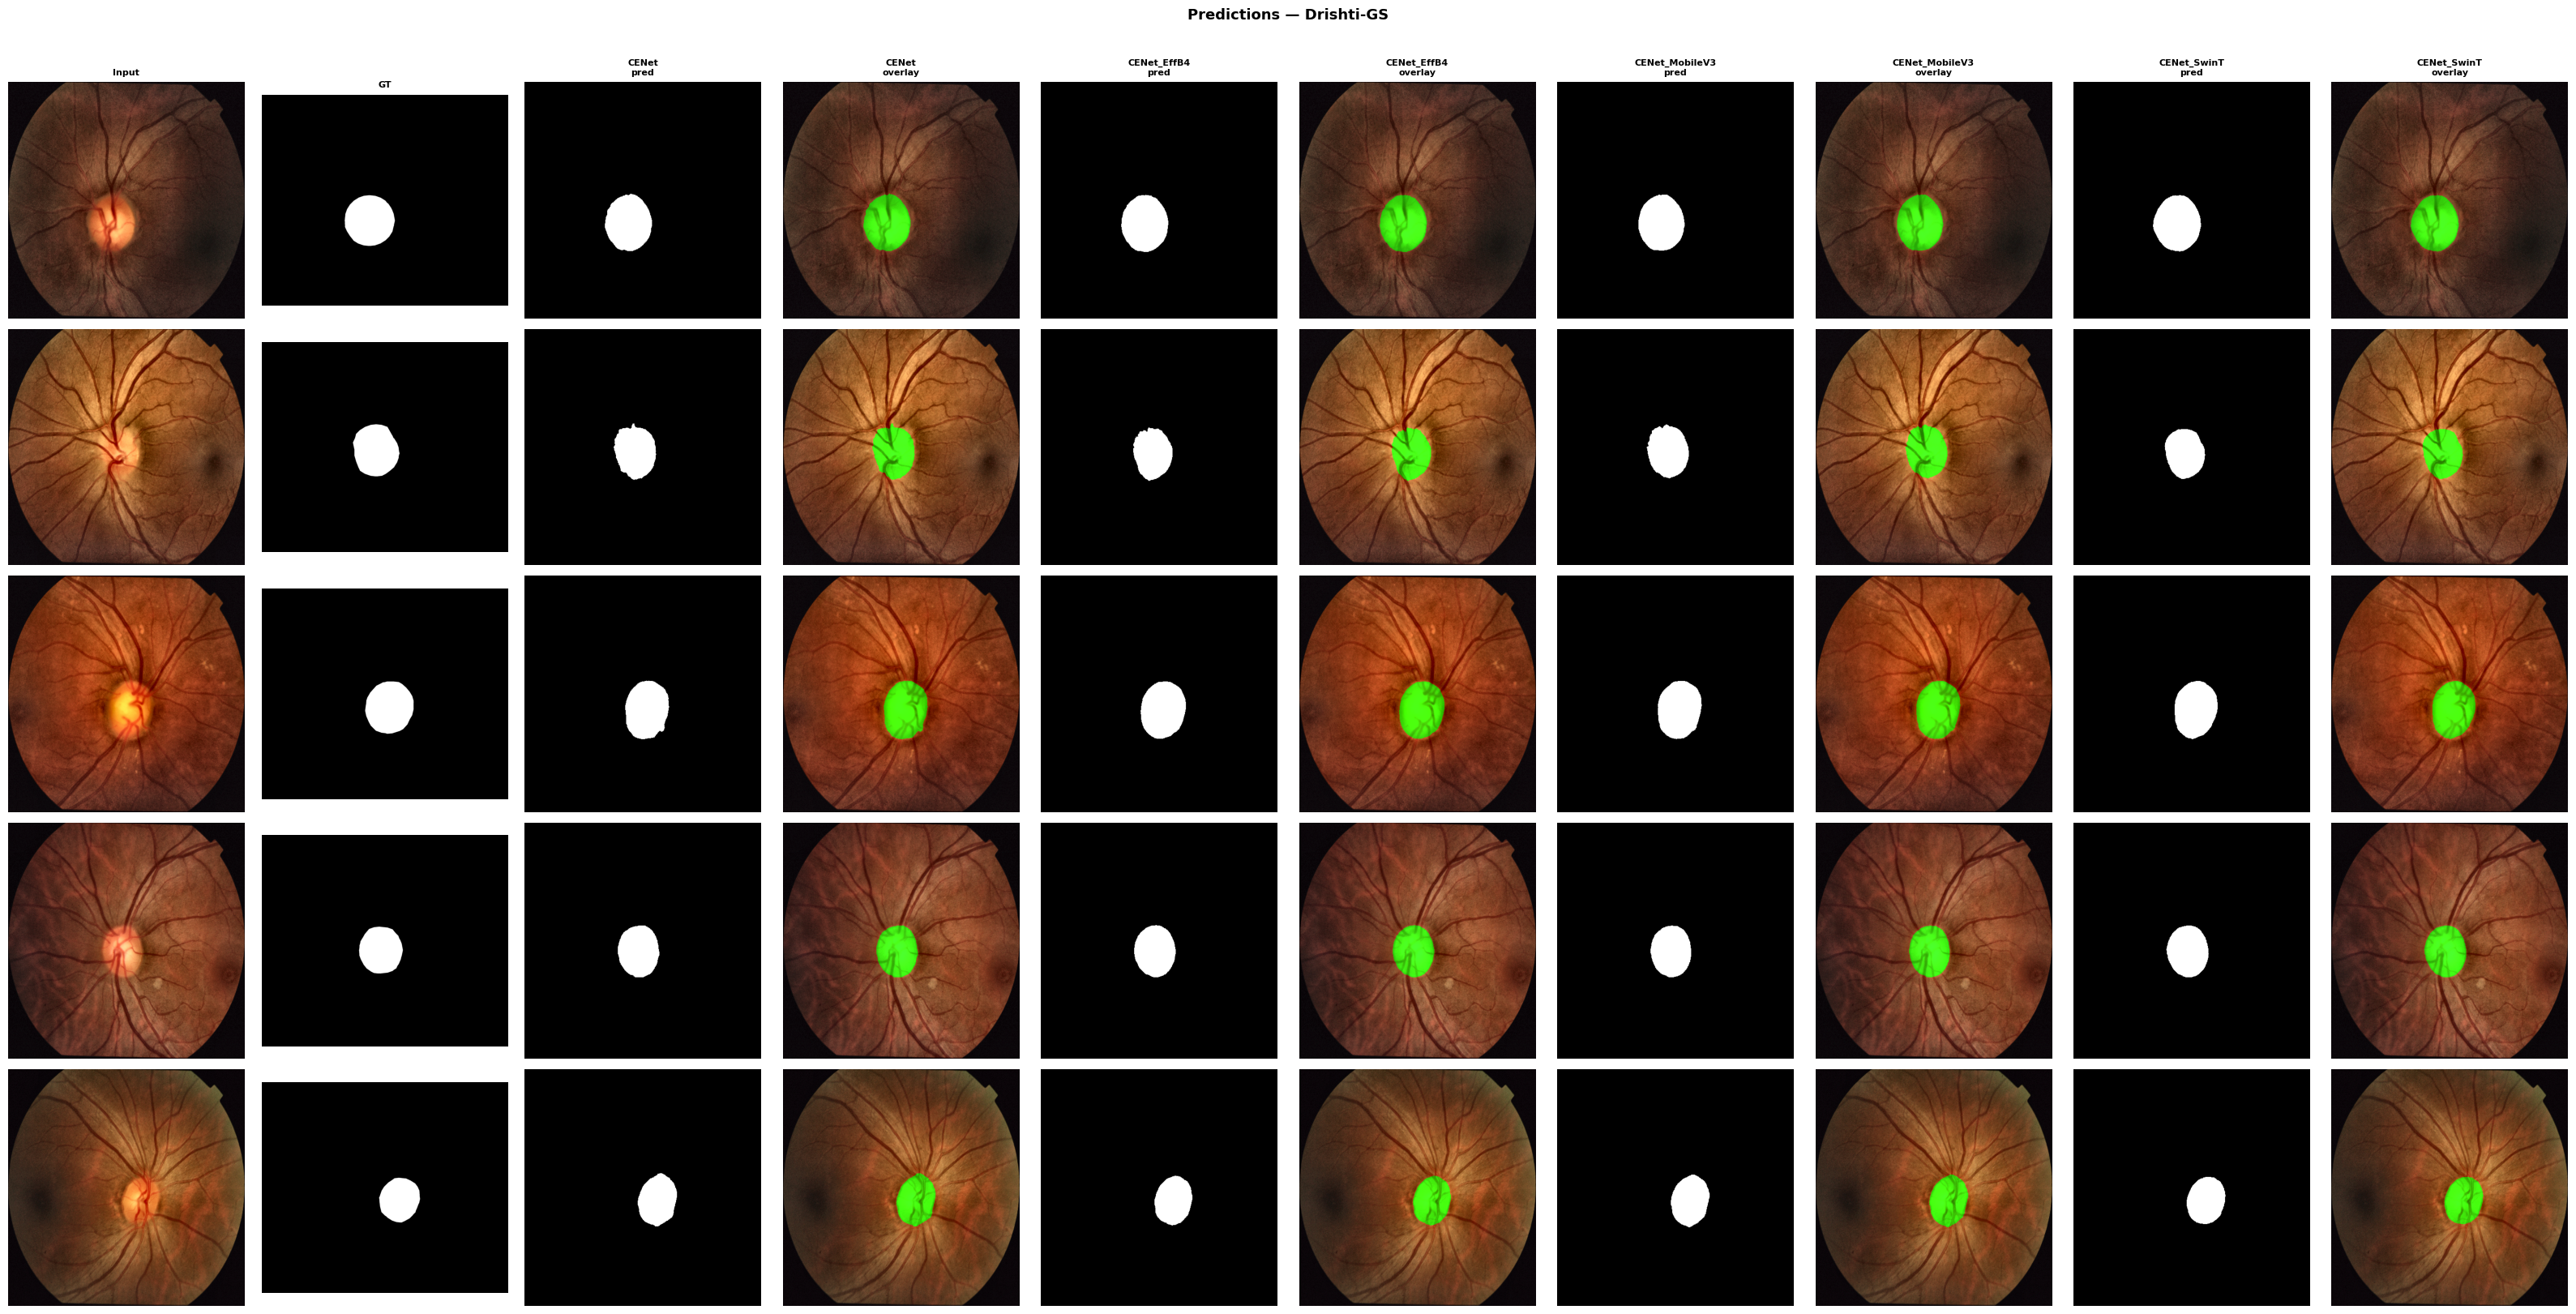

   Saved: /content/results/pred_Drishti-GS.png

 REFUGE2


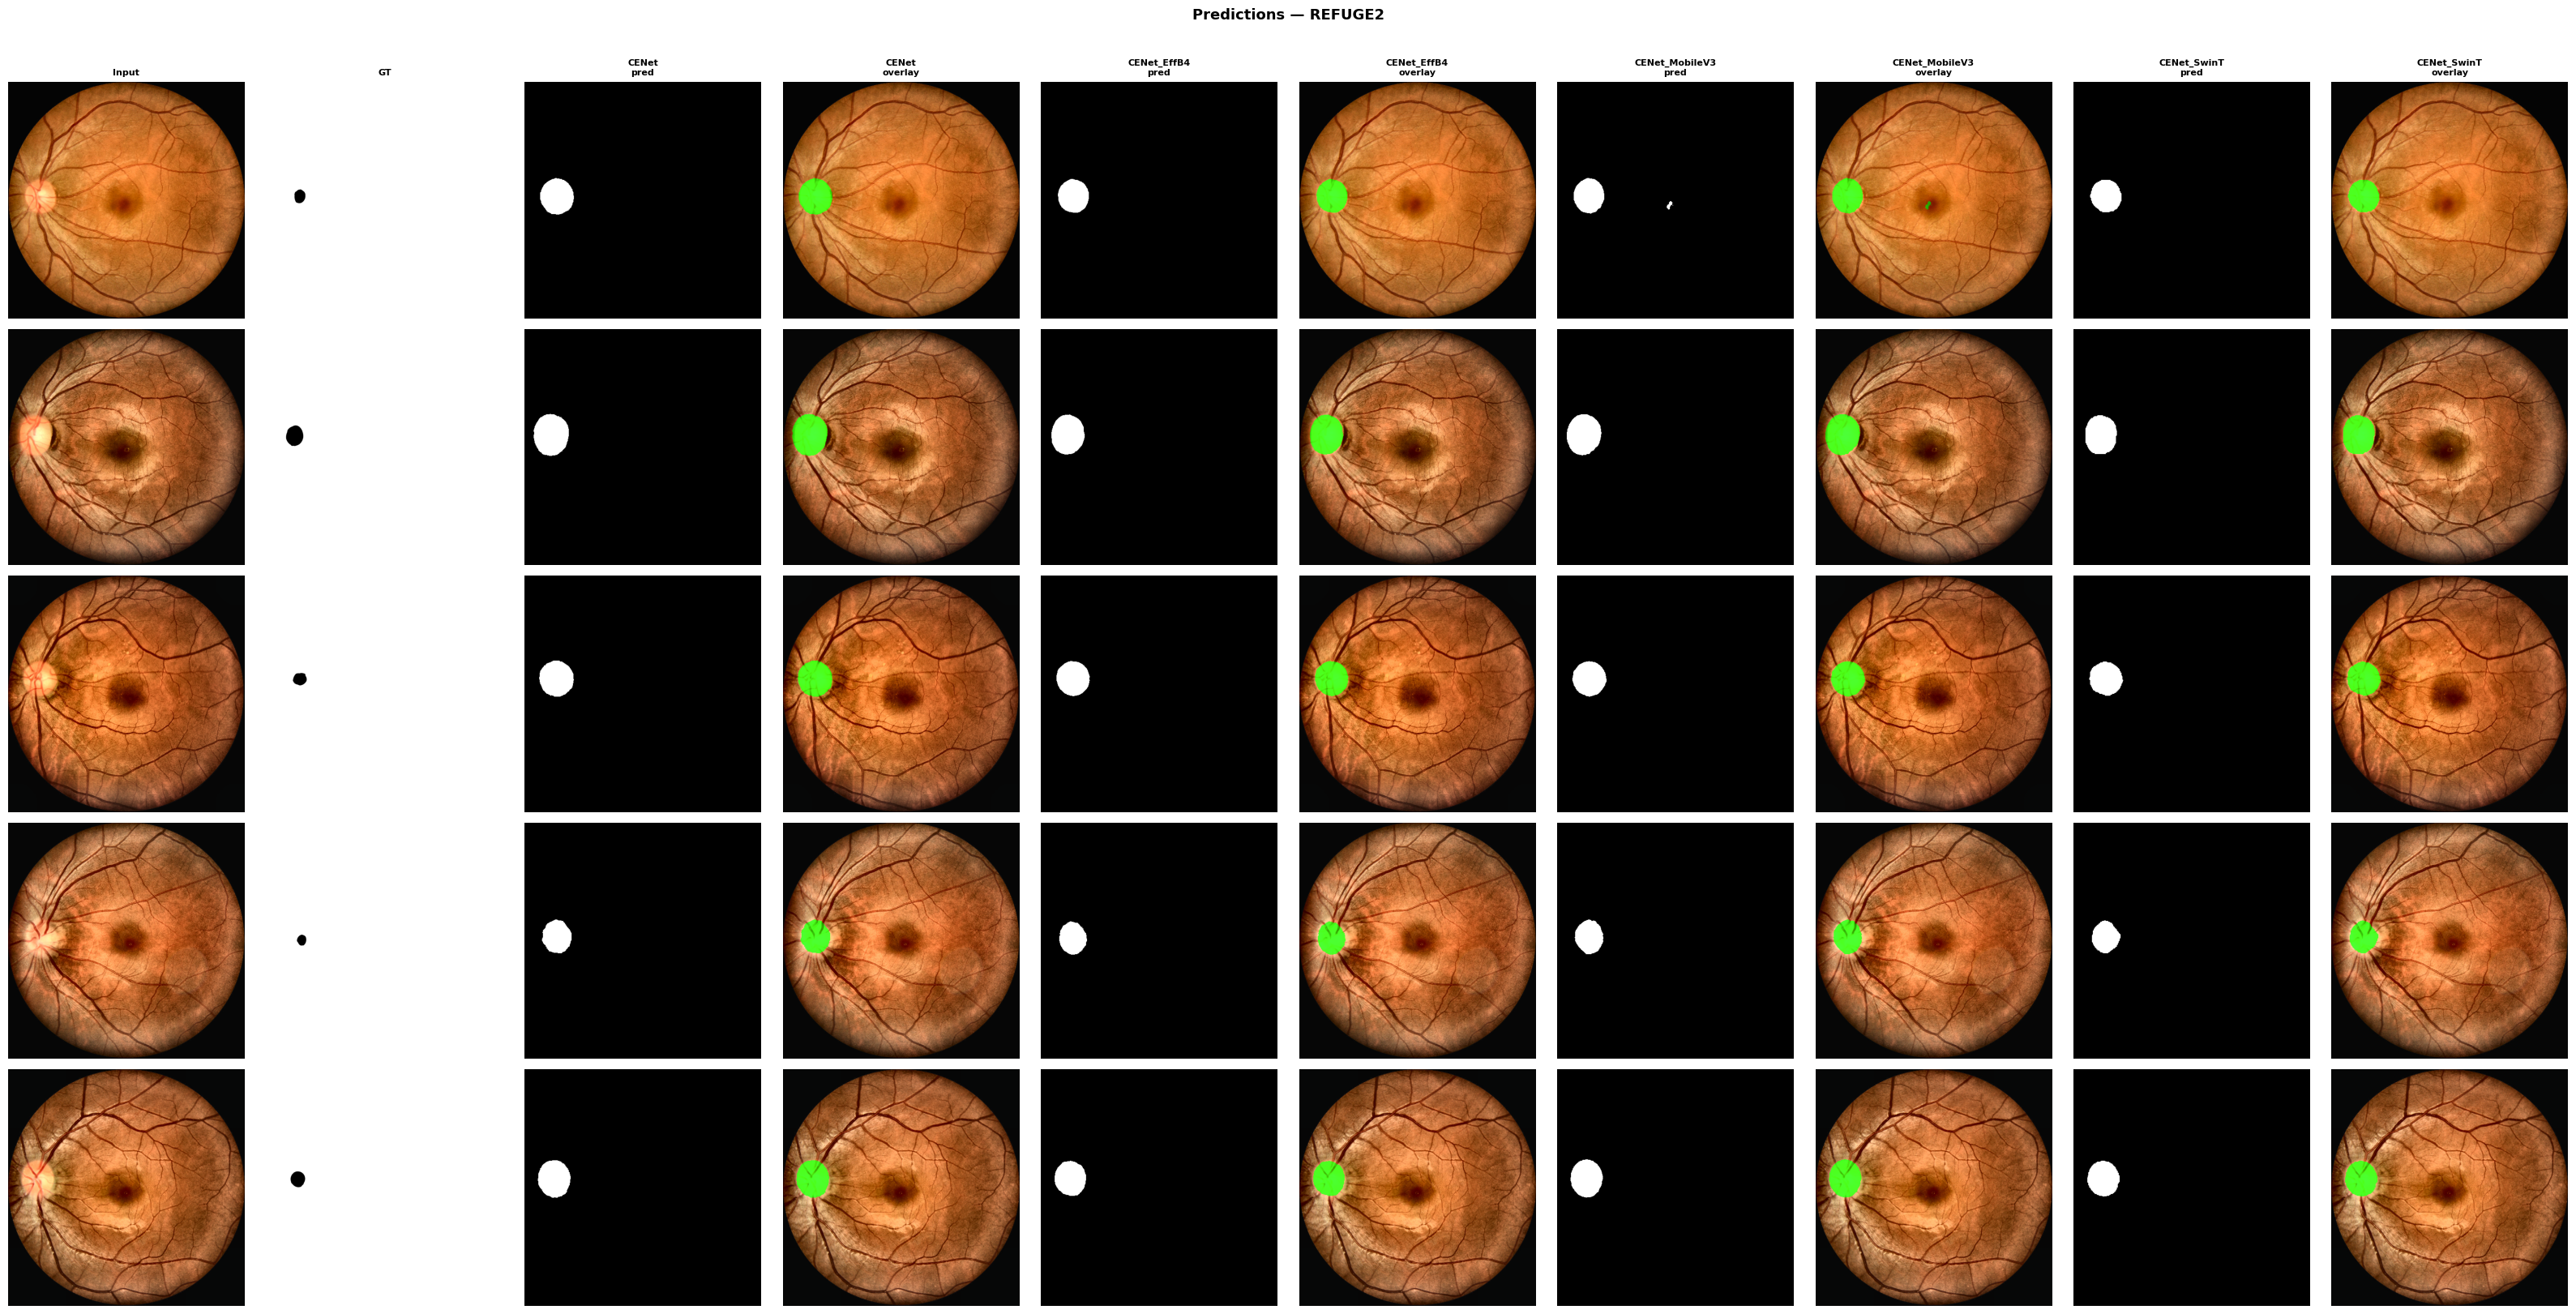

   Saved: /content/results/pred_REFUGE2.png

 Visualize xong


In [12]:
mean_np = np.array([0.485,0.456,0.406])
std_np  = np.array([0.229,0.224,0.225])

def denorm(tensor_chw):
    return np.clip(tensor_chw.permute(1,2,0).cpu().numpy()*std_np+mean_np, 0, 1)

def overlay_green(img_vis, pred_bin):
    ov = img_vis.copy()
    ov[pred_bin==1,1] = np.clip(ov[pred_bin==1,1]+0.5,0,1)
    ov[pred_bin==1,0] *= 0.3; ov[pred_bin==1,2] *= 0.3
    return ov

def load_ckpt(model_name, dataset_tag):
    ckpt = best_ckpts.get((model_name, dataset_tag))
    if not ckpt or not os.path.exists(ckpt): return None
    m = build_model(model_name)
    m.load_state_dict(torch.load(ckpt, map_location=device))
    m.eval(); return m

def viz_dataset(dataset_tag, samples_img, samples_mask, N=5):
    models_to_show = ['CENet','CENet_EffB4','CENet_MobileV3','CENet_SwinT']
    loaded = {mn: load_ckpt(mn, dataset_tag) for mn in models_to_show}
    loaded = {k:v for k,v in loaded.items() if v is not None}
    if not loaded:
        print(f"  Chưa có checkpoint cho {dataset_tag}"); return

    COLS = 2 + len(loaded)*2   # input + gt + (pred+overlay) * n_models
    fig, axes = plt.subplots(N, COLS, figsize=(3.2*COLS, 3.2*N))
    if N==1: axes=axes[None,:]
    col_titles = ["Input","GT"] + [t for mn in loaded for t in [f"{mn}\npred", f"{mn}\noverlay"]]
    for j,t in enumerate(col_titles): axes[0,j].set_title(t, fontsize=8, fontweight='bold')
    fig.suptitle(f"Predictions — {dataset_tag}", fontsize=13, fontweight='bold', y=1.01)

    for i,(img_path,mask_path) in enumerate(zip(samples_img,samples_mask)):
        raw    = np.array(Image.open(img_path).convert("RGB"))
        aug    = val_tf(image=raw)
        inp    = aug['image'].unsqueeze(0).to(device)
        img_vis= denorm(aug['image'])

        axes[i,0].imshow(img_vis); axes[i,0].axis('off')
        mask_arr = np.array(Image.open(mask_path).convert("L")) if mask_path else np.zeros(img_vis.shape[:2])
        mask_bin = (mask_arr>0).astype(np.uint8)
        axes[i,1].imshow(mask_bin,cmap='gray',vmin=0,vmax=1); axes[i,1].axis('off')

        col=2
        for mn,m in loaded.items():
            with torch.no_grad():
                prob = tta_inference(m, inp).cpu().squeeze().numpy()
            pred = (prob>0.5).astype(np.uint8)
            axes[i,col].imshow(pred,cmap='gray',vmin=0,vmax=1); axes[i,col].axis('off'); col+=1
            axes[i,col].imshow(overlay_green(img_vis,pred));     axes[i,col].axis('off'); col+=1

        axes[i,0].set_ylabel(os.path.basename(img_path),fontsize=6,rotation=0,labelpad=70,va='center')

    plt.tight_layout()
    out_p=os.path.join(SAVE_DIR,f"pred_{dataset_tag}.png")
    plt.savefig(out_p,dpi=150,bbox_inches='tight'); plt.show()
    print(f"   Saved: {out_p}")
    for m in loaded.values(): del m
    torch.cuda.empty_cache()

print("\n Drishti-GS")
all_dr=sorted(glob.glob(os.path.join(DRISHTI_TEST_IMG,'**','*.png'),recursive=True))
sample_dr=random.sample(all_dr,min(5,len(all_dr)))
s_msk_dr=[os.path.join(DRISHTI_TEST_MASK,os.path.splitext(os.path.basename(p))[0],'SoftMap',
           f"{os.path.splitext(os.path.basename(p))[0]}_ODsegSoftmap.png") for p in sample_dr]
viz_dataset('Drishti-GS',sample_dr,s_msk_dr)

# ── REFUGE2 ───────────────────────────────────────────────────────
print("\n REFUGE2")
sample_r2=random.sample(r2_va_i,min(5,len(r2_va_i)))
s_msk_r2=[next((m for m in r2_va_m if os.path.basename(p).split('.')[0] in os.path.basename(m)),p) for p in sample_r2]
viz_dataset('REFUGE2',sample_r2,s_msk_r2)

print("\n Visualize xong")



## Cell 14 — Bảng IEEE (mean ± std) + Biểu đồ


  TABLE — Quantitative Comparison (mean ± std over runs)
+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+
| Model             | Dataset           | Dice              | IoU               | Sens              | Spec              | Prec              | AUC               |
+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+
| CENet             | Drishti-GS        | 0.9613±0.0145     | 0.9258±0.0266     | 0.9775±0.0156     | 0.9982±0.0009     | 0.9463±0.0303     | 0.9998±0.0000     |
| CENet_EffB4       | Drishti-GS        | 0.9674±0.0101     | 0.9370±0.0188     | 0.9644±0.0217     | 0.9991±0.0006     | 0.9711±0.0190     | 0.9998±0.0000     |
| CENet_MobileV3    | Drishti-GS        | 0.9658±0.0122     | 0.9341±0.0225     | 0.9698±0.0169     | 0.9988±0.0008     | 0.9624±0.0

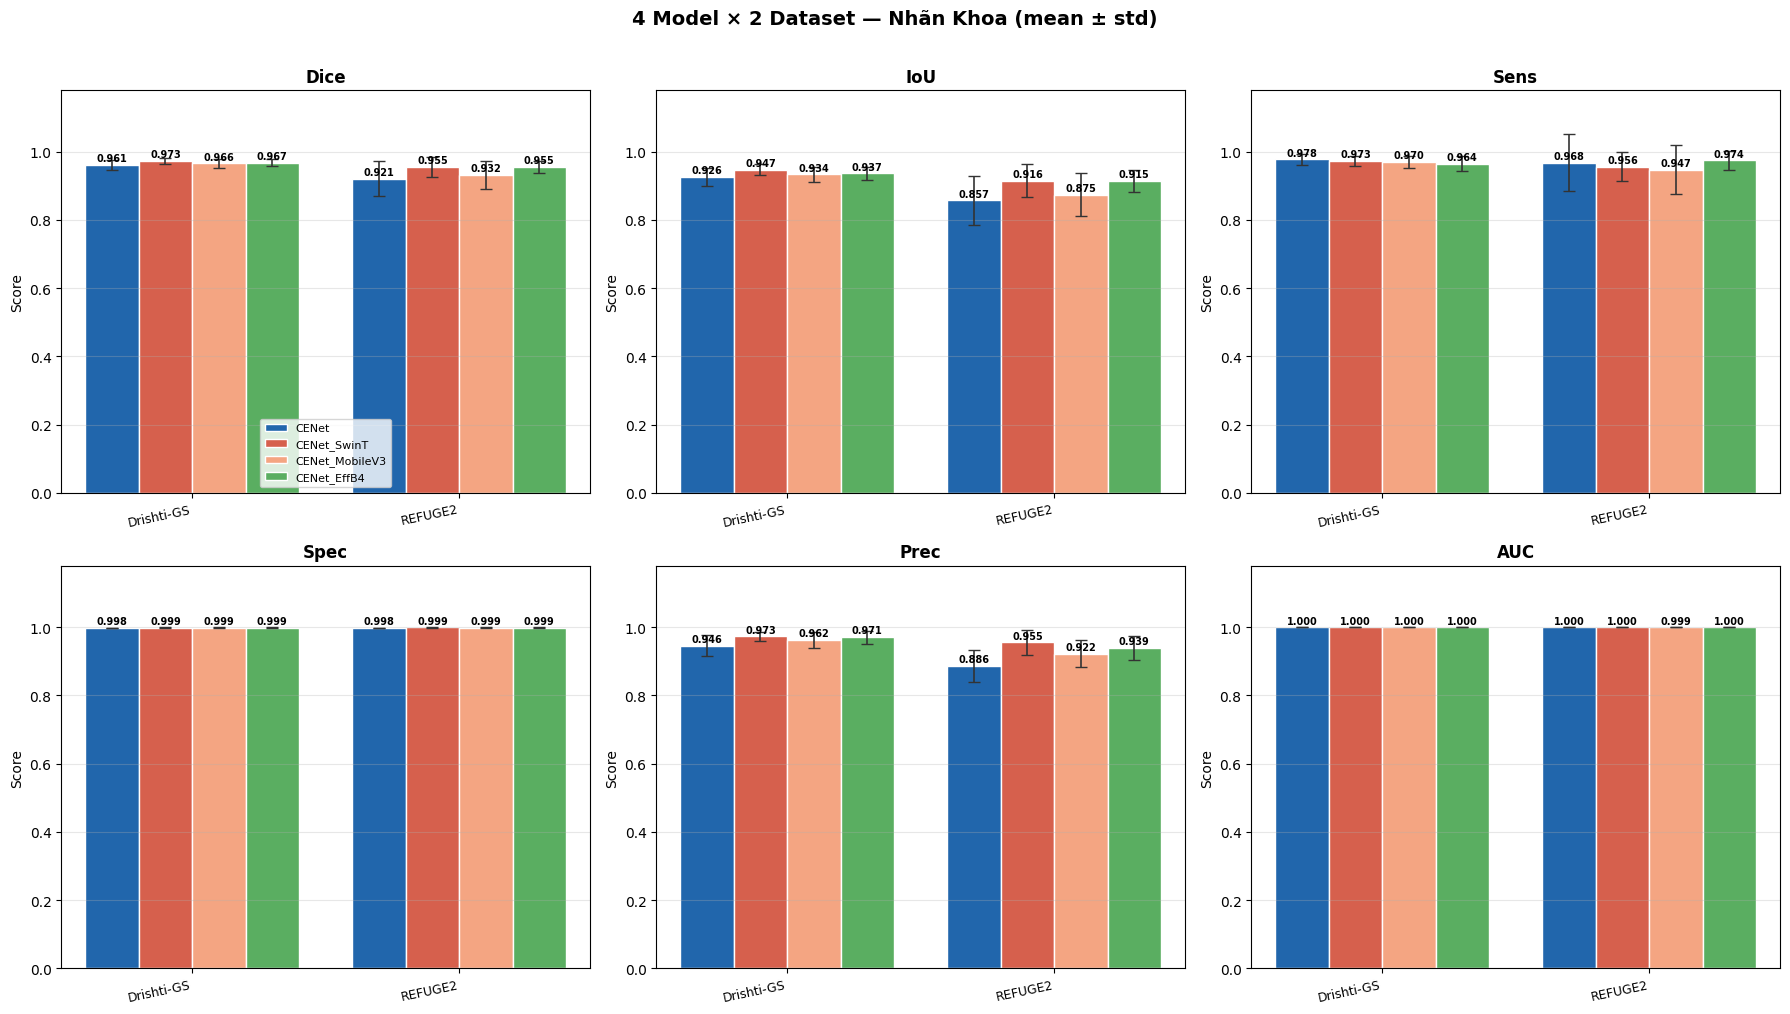

 Bar chart: /content/results/bar_ieee.png


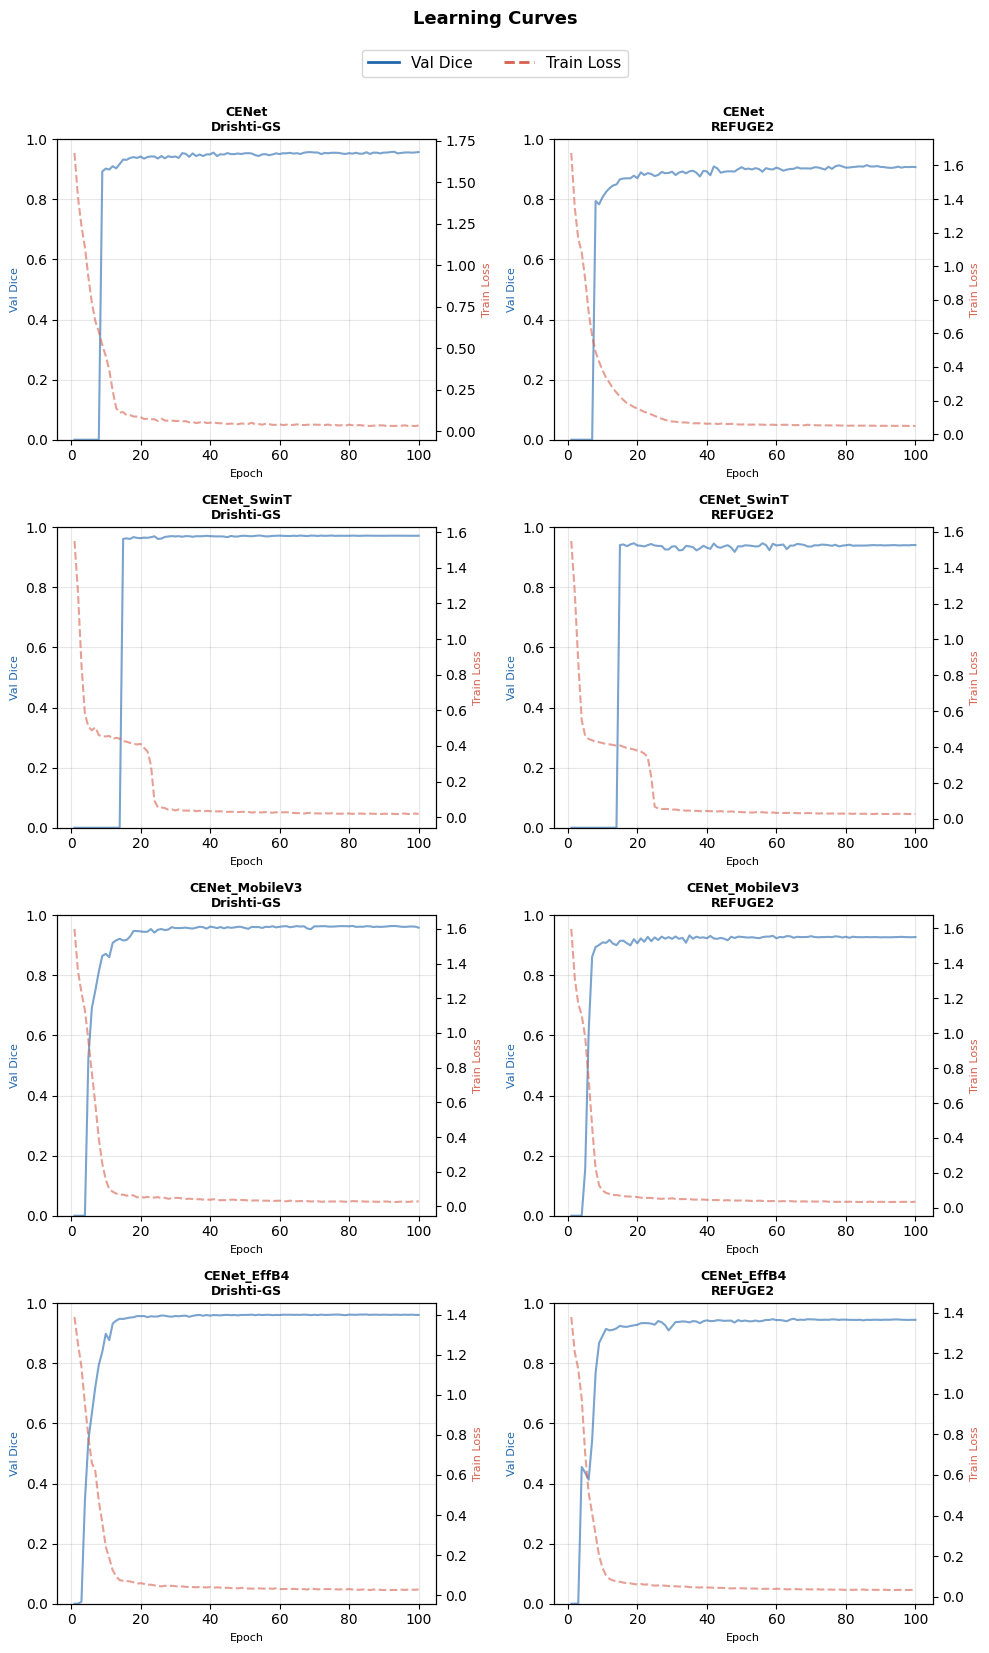

Learning curves: /content/results/learning_curves.png


In [14]:
MODELS_DISPLAY  = list(all_raw.keys())
DATASETS        = list(loaders.keys())
METRICS_DISPLAY = ['Dice', 'IoU', 'Sens', 'Spec', 'Prec', 'AUC']

# ── Tổng hợp ─────────────────────────────────────────────────────
rows = []
for model_name in MODELS_DISPLAY:
    for dataset_tag in DATASETS:
        runs = all_raw[model_name][dataset_tag]
        if not runs: continue
        row = {'Model': model_name, 'Dataset': dataset_tag}
        for m in METRICS_DISPLAY:
            vals = np.concatenate([r[m] for r in runs])
            row[m]          = np.mean(vals)
            row[f"{m}_std"] = np.std(vals)
        rows.append(row)
df_full = pd.DataFrame(rows)

# ── Bảng IEEE ────────────────────────────────────────────────────
COL_W = 17
SEP   = "+" + "+".join(["-"*(COL_W+2)]*(2+len(METRICS_DISPLAY))) + "+"
def fmt(mu, sd): return f"{mu:.4f}±{sd:.4f}"
header = (f"| {'Model':<{COL_W}} | {'Dataset':<{COL_W}} | "
          + " | ".join(f"{m:<{COL_W}}" for m in METRICS_DISPLAY) + " |")

print("\n" + "="*len(header))
print("  TABLE — Quantitative Comparison (mean ± std over runs)")
print("="*len(header))
print(SEP); print(header); print(SEP)
for _, r in df_full.sort_values(['Dataset','Model']).iterrows():
    cells_str = [f"{r['Model']:<{COL_W}}", f"{r['Dataset']:<{COL_W}}"]
    for m in METRICS_DISPLAY:
        cells_str.append(f"{fmt(r[m], r[m+'_std']):<{COL_W}}")
    print("| " + " | ".join(cells_str) + " |")
print(SEP)
print("  Metrics: Dice=F1  IoU=Jaccard  Sens=Sensitivity  Spec=Specificity  Prec=Precision  AUC=ROC-AUC")
print("  Inference: TTA 8-way (4 rotations × 2 flips).")
print("="*len(header))

csv_path = os.path.join(SAVE_DIR, 'results_ieee.csv')
df_full.to_csv(csv_path, index=False, float_format='%.4f')
print(f"\n CSV: {csv_path}")

# ── Bar chart (mean ± std) ────────────────────────────────────────
palette = {'CENet':'#2166AC', 'CENet_EffB4':'#5AAE61',
           'CENet_MobileV3':'#F4A582', 'CENet_SwinT':'#D6604D'}
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax_i, metric in enumerate(METRICS_DISPLAY):
    ax = axes[ax_i]
    x  = np.arange(len(DATASETS))
    w  = 0.2
    for j, mn in enumerate(MODELS_DISPLAY):
        color = palette.get(mn, '#888888')
        sub   = df_full[df_full['Model']==mn].set_index('Dataset')
        mus   = [sub.loc[d, metric]          if d in sub.index else 0 for d in DATASETS]
        sds   = [sub.loc[d, f"{metric}_std"] if d in sub.index else 0 for d in DATASETS]
        bars  = ax.bar(x + j*w - (len(MODELS_DISPLAY)-1)*w/2, mus, w,
                       yerr=sds, capsize=4, color=color, label=mn,
                       error_kw=dict(elinewidth=1.2, ecolor='#333'), edgecolor='white')
        for bar, mu in zip(bars, mus):
            if mu > 0:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                        f"{mu:.3f}", ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(DATASETS, fontsize=9, rotation=12, ha='right')
    ax.set_ylim(0, 1.18)
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)
    if ax_i == 0: ax.legend(fontsize=8)

plt.suptitle(f"{len(MODELS_DISPLAY)} Model × {len(DATASETS)} Dataset — Nhãn Khoa (mean ± std)",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
bar_path = os.path.join(SAVE_DIR, 'bar_ieee.png')
plt.savefig(bar_path, dpi=200, bbox_inches='tight')
plt.show()
print(f" Bar chart: {bar_path}")

# ── Learning curves ───────────────────────────────────────────────
fig, axes = plt.subplots(len(MODELS_DISPLAY), len(DATASETS),
                          figsize=(5*len(DATASETS), 4*len(MODELS_DISPLAY)))
if len(MODELS_DISPLAY) == 1: axes = axes[None, :]

for ri, mn in enumerate(MODELS_DISPLAY):
    for ci, dt in enumerate(DATASETS):
        ax  = axes[ri][ci]
        ax2 = ax.twinx()
        for run_id in range(NUM_RUNS):
            key = f"{mn}_{dt}_run{run_id}"
            if key not in all_histories: continue
            hist = all_histories[key]
            ax.plot( [h['epoch'] for h in hist], [h['dice'] for h in hist],
                     color='#2166AC', alpha=0.6, lw=1.5)
            ax2.plot([h['epoch'] for h in hist], [h['loss'] for h in hist],
                     color='#D6604D', alpha=0.6, lw=1.5, linestyle='--')
        ax.set_ylim(0, 1)
        ax.set_ylabel('Val Dice',   color='#2166AC', fontsize=8)
        ax2.set_ylabel('Train Loss',color='#D6604D', fontsize=8)
        ax.set_title(f"{mn}\n{dt}", fontsize=9, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=8)
        ax.grid(alpha=0.3)

from matplotlib.lines import Line2D
handles = [Line2D([0],[0], color='#2166AC', lw=2, label='Val Dice'),
           Line2D([0],[0], color='#D6604D', lw=2, linestyle='--', label='Train Loss')]
fig.legend(handles=handles, loc='upper center', ncol=2, fontsize=11, bbox_to_anchor=(0.5, 1.01))
plt.suptitle("Learning Curves", fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
lc_path = os.path.join(SAVE_DIR, 'learning_curves.png')
plt.savefig(lc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Learning curves: {lc_path}")


  Overlapping Error  E = 1 - IoU  (↓ càng nhỏ càng tốt)
+-------------------+-------------------+-------------------+-------------------+
| Model             | Dataset           | E (Overlap Err)   | IoU (check)       |
+-------------------+-------------------+-------------------+-------------------+
| CENet             | Drishti-GS        | 0.0742±0.0266     | 0.9258            |
| CENet_EffB4       | Drishti-GS        | 0.0630±0.0188     | 0.9370            |
| CENet_MobileV3    | Drishti-GS        | 0.0659±0.0225     | 0.9341            |
| CENet_SwinT       | Drishti-GS        | 0.0529±0.0163     | 0.9471            |
| CENet             | REFUGE2           | 0.1425±0.0720     | 0.8575            |
| CENet_EffB4       | REFUGE2           | 0.0850±0.0324     | 0.9150            |
| CENet_MobileV3    | REFUGE2           | 0.1254±0.0633     | 0.8746            |
| CENet_SwinT       | REFUGE2           | 0.0845±0.0486     | 0.9155            |
+-------------------+-------------------+

/tmp/ipykernel_1447/1363662341.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub['Model'], rotation=15, ha='right', fontsize=9)
/tmp/ipykernel_1447/1363662341.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub['Model'], rotation=15, ha='right', fontsize=9)


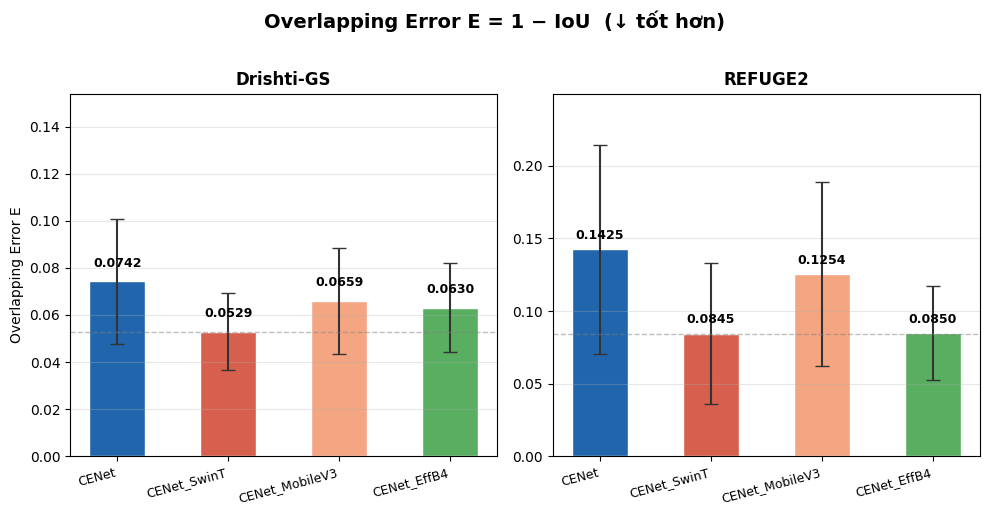

 Plot: /content/results/overlapping_error.png


In [15]:
# ═══════════════════════════════════════════════════════════════════
# OVERLAPPING ERROR — E = (FP + FN) / (TP + FP + FN) = 1 - IoU
# ═══════════════════════════════════════════════════════════════════

overlap_rows = []

for model_name in MODELS_DISPLAY:
    for dataset_tag in DATASETS:
        runs = all_raw[model_name][dataset_tag]
        if not runs: continue

        # IoU đã có sẵn trong all_raw, E = 1 - IoU
        iou_vals = np.concatenate([r['IoU'] for r in runs])
        e_vals   = 1.0 - iou_vals

        overlap_rows.append({
            'Model'  : model_name,
            'Dataset': dataset_tag,
            'E_mean' : np.mean(e_vals),
            'E_std'  : np.std(e_vals),
            'IoU_mean': np.mean(iou_vals),
        })

df_overlap = pd.DataFrame(overlap_rows)

# ── In bảng ──────────────────────────────────────────────────────
COL_W = 17
SEP   = "+" + "+".join(["-"*(COL_W+2)]*4) + "+"
header = (f"| {'Model':<{COL_W}} | {'Dataset':<{COL_W}} | "
          f"{'E (Overlap Err)':<{COL_W}} | {'IoU (check)':<{COL_W}} |")

print("\n" + "="*len(header))
print("  Overlapping Error  E = 1 - IoU  (↓ càng nhỏ càng tốt)")
print("="*len(header))
print(SEP); print(header); print(SEP)

for _, r in df_overlap.sort_values(['Dataset','Model']).iterrows():
    e_str   = f"{r['E_mean']:.4f}±{r['E_std']:.4f}"
    iou_str = f"{r['IoU_mean']:.4f}"
    print(f"| {r['Model']:<{COL_W}} | {r['Dataset']:<{COL_W}} | "
          f"{e_str:<{COL_W}} | {iou_str:<{COL_W}} |")

print(SEP)
print("  E = (FP+FN)/(TP+FP+FN) = 1 − IoU  |  mean ± std over all runs × batches")
print("="*len(header))

# ── Lưu CSV ──────────────────────────────────────────────────────
e_csv = os.path.join(SAVE_DIR, 'overlapping_error.csv')
df_overlap.to_csv(e_csv, index=False, float_format='%.4f')
print(f"\n Saved: {e_csv}")

# ── Bar chart so sánh E giữa các model ───────────────────────────
fig, axes = plt.subplots(1, len(DATASETS), figsize=(5*len(DATASETS), 5))
palette_e = {'CENet':'#2166AC','CENet_EffB4':'#5AAE61',
             'CENet_MobileV3':'#F4A582','CENet_SwinT':'#D6604D'}

for ci, dataset_tag in enumerate(DATASETS):
    ax  = axes[ci]
    sub = df_overlap[df_overlap['Dataset']==dataset_tag]
    bars = ax.bar(sub['Model'], sub['E_mean'],
                  yerr=sub['E_std'], capsize=5,
                  color=[palette_e[m] for m in sub['Model']],
                  edgecolor='white', width=0.5,
                  error_kw=dict(elinewidth=1.5, ecolor='#333'))
    for bar, mu in zip(bars, sub['E_mean']):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f"{mu:.4f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(dataset_tag, fontsize=12, fontweight='bold')
    ax.set_ylabel('Overlapping Error E' if ci==0 else '')
    ax.set_ylim(0, min(1.0, sub['E_mean'].max()*1.4 + 0.05))
    ax.set_xticklabels(sub['Model'], rotation=15, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=sub['E_mean'].min(), color='gray', linestyle='--', alpha=0.5, linewidth=1)

plt.suptitle("Overlapping Error E = 1 − IoU  (↓ tốt hơn)",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
e_plot = os.path.join(SAVE_DIR, 'overlapping_error.png')
plt.savefig(e_plot, dpi=200, bbox_inches='tight')
plt.show()
print(f" Plot: {e_plot}")

In [16]:
drive.mount('/content/drive')
ts   = datetime.now().strftime('%Y%m%d_%H%M')
dest = f'/content/drive/MyDrive/CENet_NhanKhoa_{ts}'
shutil.copytree(SAVE_DIR, dest)
print(f" Backup tại: {dest}")
for f in sorted(os.listdir(dest)):
    sz=os.path.getsize(os.path.join(dest,f))
    print(f"   {f}  ({sz/1e6:.1f} MB)" if sz>1e5 else f"   {f}")


Mounted at /content/drive
 Backup tại: /content/drive/MyDrive/CENet_NhanKhoa_20260602_2332
   CENet_Drishti-GS_run0.pth  (117.2 MB)
   CENet_EffB4_Drishti-GS_run0.pth  (91.5 MB)
   CENet_EffB4_REFUGE2_run0.pth  (91.5 MB)
   CENet_MobileV3_Drishti-GS_run0.pth  (37.4 MB)
   CENet_MobileV3_REFUGE2_run0.pth  (37.4 MB)
   CENet_REFUGE2_run0.pth  (117.2 MB)
   CENet_SwinT_Drishti-GS_run0.pth  (181.5 MB)
   CENet_SwinT_REFUGE2_run0.pth  (181.5 MB)
   bar_ieee.png  (0.2 MB)
   learning_curves.png  (0.3 MB)
   overlapping_error.csv
   overlapping_error.png  (0.1 MB)
   pred_Drishti-GS.png  (2.3 MB)
   pred_REFUGE2.png  (2.1 MB)
   results_ieee.csv
